In [3]:
from Classes.Grid import Grid
from Classes.ScalarCoeffs import ScalarCoeffs
from Classes.BoundaryConditions import BoundaryLocation, DirichletBc, NeumannBc, RobinBc
from Classes.Models import DiffusionModel, SurfaceConvectionModel, FirstOrderTransientModel, SecondOrderTransientModel, UpwindAdvectionModel, CDSAdvectionModel, QUICKAdvectionModel
from Classes.LinearSolver import solve

import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt

class AdvectingVelocityModel:
    """Class defining an advecting velocity model"""

    def __init__(self, grid, dhat, Uhe, P, U, coeffs):
        """Constructor"""
        self._grid = grid
        self._dhat = dhat
        self._Uhe = Uhe
        self._P = P
        self._U = U
        self._coeffs = coeffs

    def update(self):
        """Function to update the advecting velocity array"""

        # Calculate the pressure gradients across the faces
        gradPw = (self._P[1:-1]-self._P[0:-2])/self._grid.dx_WP
        gradPe = (self._P[2:]-self._P[1:-1])/self._grid.dx_PE
        
        # Calculate the cell pressure gradients
        gradP = 0.5*(gradPw + gradPe)
          
        # Calculate damping coefficient, dhat
        Ve = 0.5*(self._grid.vol[0:-1] + self._grid.vol[1:])
        ae = 0.5*(self._coeffs.aP[0:-1] + self._coeffs.aP[1:])
        self._dhat[1:-1] = Ve/ae

        # Update the advecting velocity
        self._Uhe[0] = self._U[0]
        self._Uhe[1:-1] = 0.5*(self._U[1:-2] + self._U[2:-1]) - self._dhat[1:-1]*(gradPe[:-1] - 0.5*(gradP[:-1] + gradP[1:]))
        self._Uhe[-1] = self._U[-1]
        
class PressureForceModel:
    """Class defining a pressure force model"""

    def __init__(self, grid, P, west_bc, east_bc):
        """Constructor"""
        self._grid = grid
        self._P = P
        self._west_bc = west_bc
        self._east_bc = east_bc

    def add(self, coeffs):
        """Function to add diffusion terms to coefficient arrays"""

        # Calculate the pressure force
        gradPw = (self._P[1:-1]-self._P[0:-2])/self._grid.dx_WP
        gradPe = (self._P[2:]-self._P[1:-1])/self._grid.dx_PE
        force = 0.5*(gradPw + gradPe)*self._grid.vol
          
        # Calculate the linearization coefficients
        coeffW = - 0.5*self._grid.vol/self._grid.dx_WP
        coeffE = 0.5*self._grid.vol/self._grid.dx_PE
        coeffP = - coeffW - coeffE

        # Modify the linearization coefficients on the boundaries
        coeffP[0] += coeffW[0]*self._west_bc.coeff()
        coeffP[-1] += coeffE[-1]*self._east_bc.coeff()

        # Zero the boundary coefficients that are not used
        coeffW[0] = 0.0
        coeffE[-1] = 0.0

        # Add to coefficient arrays
        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_aW(coeffW)
        coeffs.accumulate_aE(coeffE)
        coeffs.accumulate_rP(force)

        # Return the modified coefficient array
        return coeffs
        
class MassConservationEquation:
    """Class defining a mass conservation equation"""

    def __init__(self, grid, U, P, dhat, Uhe, rho, 
                 P_west_bc, P_east_bc, U_west_bc, U_east_bc):
        """Constructor"""
        self._grid = grid
        self._U = U
        self._P = P
        self._dhat = dhat
        self._Uhe = Uhe
        self._rho = rho
        self._P_west_bc = P_west_bc
        self._P_east_bc = P_east_bc
        self._U_west_bc = U_west_bc
        self._U_east_bc = U_east_bc

    def add(self, PP_coeffs, PU_coeffs):
        """Function to add diffusion terms to coefficient arrays"""

        # Calculate the mass imbalance, based on advecting velocities
        imbalance = self._rho*self._grid.Ae*self._Uhe[1:] - self._rho*self._grid.Aw*self._Uhe[:-1]
              
        # Calculate the linearization coefficients on pressure
        PP_coeffW = np.concatenate((np.array([0]), -self._rho*self._grid.Aw[1:]*self._dhat[1:-1]/self._grid.dx_WP[1:]))
        PP_coeffE = np.concatenate((-self._rho*self._grid.Ae[:-1]*self._dhat[1:-1]/self._grid.dx_PE[:-1], np.array([0])))
        PP_coeffP = - PP_coeffW - PP_coeffE
        
        # Calculate the linearization coefficients on velocity
        PU_coeffW = np.concatenate((np.array([-self._rho*self._grid.Aw[0]]), -0.5*self._rho*self._grid.Aw[1:]))
        PU_coeffE = np.concatenate((0.5*self._rho*self._grid.Ae[:-1], np.array([self._rho*self._grid.Ae[-1]])))
        PU_coeffP = np.concatenate((np.array([0]), PU_coeffW[1:])) + np.concatenate((PU_coeffE[:-1], np.array([0])))

        # Modify the linearization coefficients on the boundaries 
        # (velocity only, since pressure is already zero)
        PU_coeffP[0] += PU_coeffW[0]*self._U_west_bc.coeff()
        PU_coeffP[-1] += PU_coeffE[-1]*self._U_east_bc.coeff()

        # Zero the boundary coefficients that are not used
        PU_coeffW[0] = 0.0
        PU_coeffE[-1] = 0.0

        # Add to coefficient arrays
        PP_coeffs.accumulate_aP(PP_coeffP)
        PP_coeffs.accumulate_aW(PP_coeffW)
        PP_coeffs.accumulate_aE(PP_coeffE)
        PP_coeffs.accumulate_rP(imbalance)
        PU_coeffs.accumulate_aP(PU_coeffP)
        PU_coeffs.accumulate_aW(PU_coeffW)
        PU_coeffs.accumulate_aE(PU_coeffE)

        # Return the modified coefficient arrays
        return PP_coeffs, PU_coeffs

class ExtrapolatedBc:
    """Class defining an extrapolated boundary condition"""

    def __init__(self, phi, grid, loc):
        """Constructor
            phi ........ field variable array
            grid ....... grid
            loc ........ boundary location
        """
        self._phi = phi
        self._grid = grid
        self._loc = loc

    def value(self):
        """Return the boundary condition value"""
        if self._loc is BoundaryLocation.WEST:
            return (self._phi[1] - ((self._phi[2] - self._phi[1]) / self._grid.dx_PE[0]) * self._grid.dx_WP[0])

        elif self._loc is BoundaryLocation.EAST:
            return (self._phi[-2] + ((self._phi[-2] - self._phi[-3]) / self._grid.dx_WP[-1]) * self._grid.dx_PE[-1])
        else:
            raise ValueError("Unknown boundary location")

    def coeff(self):
        """Return the linearization coefficient"""
        if self._loc is BoundaryLocation.WEST:
            return 1 + self._grid.dx_WP[0] / self._grid.dx_PE[0]
        elif self._loc is BoundaryLocation.EAST:
            return  1 + self._grid.dx_PE[-1] / self._grid.dx_WP[-1]
        else:
            raise ValueError("Unknown boundary location")

    def apply(self):
        """Applies the boundary condition in the referenced field variable array"""
        if self._loc is BoundaryLocation.WEST:
            pass # Fill in expression below
            self._phi[0] =  (self._phi[1] - ((self._phi[2] - self._phi[1]) / self._grid.dx_PE[0]) * self._grid.dx_WP[0])
        elif self._loc is BoundaryLocation.EAST:
            pass # Fill in expression below
            self._phi[-1] = (self._phi[-2] + ((self._phi[-2] - self._phi[-3]) / self._grid.dx_WP[-1]) * self._grid.dx_PE[-1])
        else:
            raise ValueError("Unknown boundary location")

# Assignment 4 - Solution of Mass and Momentum Equations

Solve the following problems and explain your results.

Solve all problems using water as the fluid with $\rho=1000$ [kg/m$^3$], $\mu=1 \times 10^{-3}$ [kg/m$\cdot$s].  Problems 1-2 should be solved for a 4 [m] long, 0.02 $\times$ 0.02 [m] cross-section duct discretized using 10 equal-length control-volumes.  Also, for simplicity, use UDS as your advection scheme for problems 1-2.  Higher-order advection schemes are considered in question 3.

Heat transfer is not considered in these problems, so the energy equation does not need to be solved.

## Problem 1

For $\tau_w=0$, set $u = \hat{u} = 10$ [m/s] and $p = 0$ [Pa] everywhere as initial conditions.  These are the exact solutions to the mass and momentum equations for constant duct area.  Do one time step (using any time step size) and make sure that your code accepts this as the exact solution.  Repeat this problem with $u = \hat{u} = -10$ [m/s] to ensure that your code has no directional dependence.  Describe the boundary conditions used for the two cases, including the values of $\alpha_e$.

In [22]:
# Define the grid
lx = 4.0
ly = 0.02
lz = 0.02
ncv = 10
grid = Grid(lx, ly, lz, ncv)

# Set the timestep information
nTime = 1
dt = 1e9
time = 0

# Set the maximum number of iterations and convergence criterion
maxIter = 100
converged = 1e-6

# Define thermophysical properties
rho = 1000
mu = 1e-3

# Define the coefficients
PU_coeffs = ScalarCoeffs(grid.ncv)
PP_coeffs = ScalarCoeffs(grid.ncv)
UP_coeffs = ScalarCoeffs(grid.ncv)
UU_coeffs = ScalarCoeffs(grid.ncv)

# Initial conditions
U0 = 10
P0 = 0

# Initialize field variable arrays
U = U0*np.ones(grid.ncv+2)
P = P0*np.ones(grid.ncv+2)

# Initialize advecting velocity and damping coefficient array
dhat = np.zeros(grid.ncv+1)
Uhe = U0*np.ones(grid.ncv+1)

# Define boundary conditions for velocity
U_west_bc = DirichletBc(U, grid, U0, BoundaryLocation.WEST)
U_east_bc = NeumannBc(U, grid, 0, BoundaryLocation.EAST)

# Define boundary conditions for pressure
#   - Once ExtrapolatedBc is complete, change the boundary condition
P_west_bc = ExtrapolatedBc(P, grid, BoundaryLocation.WEST)
P_east_bc = DirichletBc(P, grid, 0, BoundaryLocation.EAST)

# Apply boundary conditions
U_west_bc.apply()
U_east_bc.apply()
P_west_bc.apply()
P_east_bc.apply()

# Define the transient model
Uold = np.copy(U)
transient = FirstOrderTransientModel(grid, U, Uold, rho, 1, dt)

# Define the diffusion model
diffusion = DiffusionModel(grid, U, mu, U_west_bc, U_east_bc)

# Define the advection model
advection = UpwindAdvectionModel(grid, U, Uhe, rho, 1, U_west_bc, U_east_bc)

# Define the pressure force model
pressure = PressureForceModel(grid, P, P_west_bc, P_east_bc)

# Define advecting velocity model
advecting = AdvectingVelocityModel(grid, dhat, Uhe, P, U, UU_coeffs)

# Define conservation of mass equation
mass = MassConservationEquation(grid, U, P, dhat, Uhe, rho, 
                                P_west_bc, P_east_bc, U_west_bc, U_east_bc)

# Loop through all timesteps
for tStep in range(nTime):
    # Update the time information
    time += dt
    
    # Print the timestep information
    print("Timestep = {}; Time = {}".format(tStep, time))
    
    # Store the "old" velocity field
    Uold[:] = U[:]
    
    # Iterate until the solution is converged
    for i in range(maxIter):
        
        # Zero all of the equations
        PP_coeffs.zero()
        PU_coeffs.zero()
        UU_coeffs.zero()
        UP_coeffs.zero()     
        
        # Assemble the momentum equations
        #   Note: do this before mass, because the coeffs are needed to compute advecting velocity
        UU_coeffs = diffusion.add(UU_coeffs)
        UU_coeffs = advection.add(UU_coeffs)
        UU_coeffs = transient.add(UU_coeffs)
        UP_coeffs = pressure.add(UP_coeffs)
        
        # Assemble the mass equations
        advecting.update()
        PP_coeffs, PU_coeffs = mass.add(PP_coeffs, PU_coeffs)

        # Compute residuals and check for convergence
        PmaxResid = norm(PU_coeffs.rP + PP_coeffs.rP, np.inf)
        PavgResid = np.mean(np.absolute(PU_coeffs.rP + PP_coeffs.rP))
        UmaxResid = norm(UU_coeffs.rP + UP_coeffs.rP, np.inf)
        UavgResid = np.mean(np.absolute(UU_coeffs.rP + UP_coeffs.rP))
        print("Iteration = {}.".format(i))
        print("  Mass:     Max. Resid. = {}; Avg. Resid. = {}".format(PmaxResid, PavgResid))
        print("  Momentum: Max. Resid. = {}; Avg. Resid. = {}".format(UmaxResid, UavgResid))
        if PmaxResid < converged and UmaxResid < converged:
            break
    
        # Solve the sparse matrix system
        dP, dU = solve(PP_coeffs, PU_coeffs, UP_coeffs, UU_coeffs)
    
        # Update the solutions 
        P[1:-1] += dP
        U[1:-1] += dU
        
        # Update boundary conditions
        U_west_bc.apply()
        U_east_bc.apply()
        P_west_bc.apply()
        P_east_bc.apply()
        
        # Update the advecting velocities
        advecting.update()


Timestep = 0; Time = 1000000000.0
Iteration = 0.
  Mass:     Max. Resid. = 0.0; Avg. Resid. = 0.0
  Momentum: Max. Resid. = 0.0; Avg. Resid. = 0.0


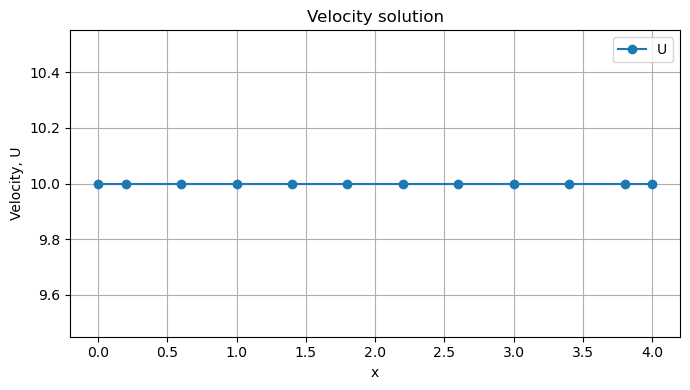

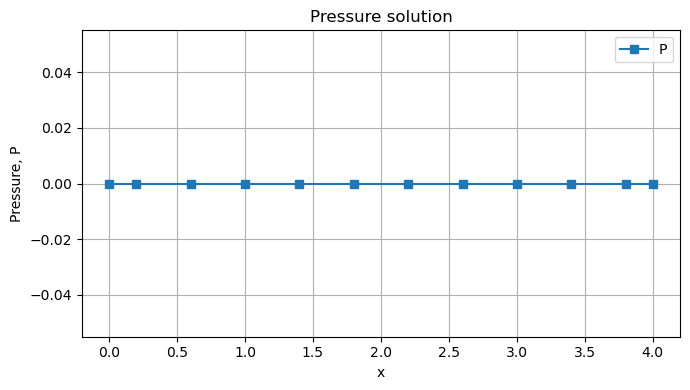

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Interior cell-center locations
xP = grid.xP

# Full array including boundary/ghost values
# Assumption: west boundary at x = 0, east boundary at x = lx

x_full = grid.xP


# Plot velocity U

plt.figure(figsize=(7, 4))

plt.plot(
    x_full,
    U,
    marker="o",
    linestyle="-",
    label="U"
)

plt.xlabel("x")
plt.ylabel("Velocity, U")
plt.title("Velocity solution")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot pressure P

plt.figure(figsize=(7, 4))

plt.plot(
    x_full,
    P,
    marker="s",
    linestyle="-",
    label="P"
)

plt.xlabel("x")
plt.ylabel("Pressure, P")
plt.title("Pressure solution")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Problem 2

For turbulent flow in a long duct, the wall shear stress can be approximated by:

$$
    \frac{\tau_w}{\frac{1}{2} \rho U^2} = C_f = (1.58 \ln(Re)-3.28)^{-2}
$$

where $Re=\rho D_h U/\mu > 10^4$ and $D_h=4A/P_o$ is the hydraulic diameter of the duct.  Implement the wall shear stress model into your code and  linearize appropriately.  Note that the force on a control-volume can be computed using the above expression as:

$$
    F_u = \tau_w A_o = C_f \frac{1}{2} \rho U^2 A_o
$$

Note that $C_f$ changes very slowly with $U$, so you will only need to linearize the $U^2$ term (not the implicit dependence of $Re$ on $U$).  Impose suitable boundary conditions on the ends of the duct and initialize the problem with $u = \hat{u} = 10$ [m/s] and $p = 0$ [Pa].  Check that the pressure is exactly correct after emerging from enough iterations by comparing your result with the exact solution calculated from the above expressions. Why is the result not correct after the first iteration?

## Problem 3

In this problem, we explore the flow in a frictionless converging-diverging circular duct.  We will now consider the utility of second-order advection schemes to explore errors associated with UDS.  Implement the CDS and QUICK schemes into the momentum equation.  You can essentially use what you created in the previous assignment for this task.

![Duct](Figures/4-Duct.png)

The duct is defined by:
$$
    r=2H_t + H_t cos \left( 2\pi \frac{x}{L} \right)
$$

where $L=1$ [m], $H_t=0.01$ [m].  You will have to modify the `Grid` class in order to solve this problem. Keep the general structure of the class, but modify the calculation of the areas and volumes appropriately. The inlet velocity should be imposed as $u=2$ [m/s].  To eliminate friction in the duct, be sure to turn off the wall friction terms from the previous problem.  Solve the problem using 8, 16, 32 and 64 equal-length control-volumes and calculate the loss in dynamic head from each converged solution.  The dynamic head loss is given as:

$$
    C_D= \frac{P_{in} - P_{out}}{\frac{1}{2} \rho U_{in}^2}
$$

Compare your solutions from UDS with those from the second-order schemes and quantify the convergence characteristics of each.  Plot the velocities and pressures versus $x$ for enough of the cases to visualize the results properly.  What should $C_D$ become for this problem?